# Per-Asset Model Training

There are 8 crytoassets in total. For each cryptoasset, train two LSTM models:
- Baseline model (without regime label)
- Regime-aware model (with regime label)

**Hyperparameter Tuning with Rolling-Window Cross-Validation:**

To tune hyperparameters, use rolling-window cross-validation. 

Hyperparameters in consideration:
1. learning rate
2. hidden units
3. dropout

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import TensorDataset, DataLoader
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [4]:
# # Uncomment if wish to clear models directory before training of models
# import os
# import shutil

# MODEL_DIR = "models"

# # Check if directory exists
# if os.path.exists(MODEL_DIR):
#     # Delete all contents inside the folder
#     for filename in os.listdir(MODEL_DIR):
#         file_path = os.path.join(MODEL_DIR, filename)
#         try:
#             if os.path.isfile(file_path) or os.path.islink(file_path):
#                 os.unlink(file_path)  # remove file or symlink
#             elif os.path.isdir(file_path):
#                 shutil.rmtree(file_path)  # remove folder recursively
#         except Exception as e:
#             print(f"Failed to delete {file_path}. Reason: {e}")
#     print(f"Cleared all contents of '{MODEL_DIR}' directory.")
# else:
#     print(f"Directory '{MODEL_DIR}' does not exist.")

In [5]:
# --- reproducibility ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

Using device: cpu


In [6]:
# --- LSTM model ---
class CryptoLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(CryptoLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: [batch_size, seq_len, input_size]
        out, _ = self.lstm(x)     # out: [batch_size, seq_len, hidden_size]
        out = out[:, -1, :]  # take last timestep
        out = self.fc(out)   # [batch_size, 1]
        return out

In [7]:
def train_model(
    model,
    train_loader,
    val_loader,
    lr=0.001,
    epochs=30,
    patience=5,
    device='cpu'
):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=0
    )

    train_losses = []
    val_losses = []

    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)
        train_losses.append(train_loss)

        # ===== VALIDATION =====
        model.eval()
        val_loss = 0.0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                output = model(X_batch)
                loss = criterion(output, y_batch)
                val_loss += loss.item() * X_batch.size(0)

        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)

        # scheduler step
        scheduler.step(val_loss)

        # ===== BEST MODEL TRACKING =====
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        # ===== PRINT =====
        # print(f"Epoch {epoch+1}: Train={train_loss:.6f}, Val={val_loss:.6f}")

        # ===== EARLY STOPPING =====
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # restore best model
    model.load_state_dict(best_state)

    metadata = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "epochs_trained": len(train_losses)
    }

    return model, best_val_loss, metadata


def predict_model(model, X):
    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)

    with torch.no_grad():
        preds = model(X_tensor).cpu().numpy().flatten()
    return preds


def rolling_window_cv(X, y, n_splits=3, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    train_len = int(train_ratio * n)
    val_len = int(val_ratio * n)

    splits = []
    for i in range(n_splits):
        start = int(i * (n - train_len - val_len) / max(n_splits - 1, 1))
        train_idx = range(start, start + train_len)
        val_idx = range(start + train_len, start + train_len + val_len)

        if val_idx[-1] < n:
            splits.append((train_idx, val_idx))

    return splits

In [8]:
# --- forecasting evaluation functions ---
def mse_score(y_true, y_pred):
    """Mean Squared Error"""
    return np.mean((y_true - y_pred) ** 2)

def directional_accuracy(y_true, y_pred):
    """Directional accuracy: % times model predicts correct sign"""
    return np.mean(np.sign(y_true) == np.sign(y_pred))

# --- save final result function ---
def save_asset_results(
    asset,
    best_base,
    best_val_base,
    best_reg,
    best_val_reg,
    mse_no_regime,
    mse_with_regime,
    da_no_regime,
    da_with_regime,
    model_dir="models"
):
    """
    Save or append training/evaluation results for a single asset to all_results.npy.
    """
    os.makedirs(model_dir, exist_ok=True)
    all_results_file = os.path.join(model_dir, "all_results.npy")
    
    # load existing results
    if os.path.exists(all_results_file):
        all_results = np.load(all_results_file, allow_pickle=True).item()
    else:
        all_results = {}
    
    result_entry = {
        "asset": asset,
        "mse_no_regime": mse_no_regime,
        "mse_with_regime": mse_with_regime,
        "da_no_regime": da_no_regime,
        "da_with_regime": da_with_regime
    }
    
    if asset in all_results:
        # append new result to existing list
        all_results[asset]["results"].append(result_entry)
        # update configs in case hyperparameters improved
        all_results[asset]["baseline"]["config"] = best_base
        all_results[asset]["baseline"]["best_val_loss"] = best_val_base
        all_results[asset]["regime"]["config"] = best_reg
        all_results[asset]["regime"]["best_val_loss"] = best_val_reg
    else:
        all_results[asset] = {
            "baseline": {
                "config": best_base,
                "best_val_loss": best_val_base
            },
            "regime": {
                "config": best_reg,
                "best_val_loss": best_val_reg
            },
            "results": [result_entry]
        }
    
    np.save(all_results_file, all_results)

The following code cell can be edited to test different hyperparameters.
- `N_SEACRH`: number of combinations to randomly sample for random search
- Uncomment the corresponding lines for random search and grid search

In [9]:
# --- hyperparameter grid ---
param_grid = {
    'learning_rate': [0.001, 0.0005, 0.0001, 0.00005],
    'hidden_size': [64, 128],
    'dropout': [0.1, 0.2, 0.3],
}

# random search
N_SEARCH = 5
param_list = random.sample(list(itertools.product(*param_grid.values())), k=N_SEARCH) 

# grid search
# param_list = list(itertools.product(*param_grid.values())) # grid search

random.shuffle(param_list)
param_names = list(param_grid.keys())

assets = [
    "BTCUSDT", 
    "ETHUSDT", 
    "BNBUSDT", 
    "ADAUSDT",
    "XRPUSDT", 
    "LTCUSDT", 
    "BCHUSDT", 
    "LINKUSDT"
]

BATCH_SIZE = 64

## Training loop

In [ ]:
# directory to save models
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# --- training loop per asset ---
all_results = {}
for asset in assets:
    if os.path.exists(f"{MODEL_DIR}/baseline_{asset}.pt") and os.path.exists(f"{MODEL_DIR}/regime_{asset}.pt"):
        print(f"Skipping {asset} (already completed)")
        continue
    print(f"\n===== {asset} =====")

    # load full feature data
    X_train_full = np.load(f"lstm_ready_data/X_train_{asset}.npy")
    y_train = np.load(f"lstm_ready_data/y_train_{asset}.npy")
    X_val_full = np.load(f"lstm_ready_data/X_val_{asset}.npy")
    y_val = np.load(f"lstm_ready_data/y_val_{asset}.npy")

    # split features
    X_train_baseline = X_train_full[:, :, :-1]   # exclude regime
    X_val_baseline = X_val_full[:, :, :-1]

    X_train_regime = X_train_full               # include regime
    X_val_regime = X_val_full

    
    def tune_model(X, y, input_size):
        best_config = None
        best_loss = float('inf')

        for params in param_list:
            param_dict = dict(zip(param_names, params))
            splits = rolling_window_cv(X, y)
            losses = []

            for train_idx, val_idx in splits:
                X_tr, y_tr = X[list(train_idx)], y[list(train_idx)]
                X_va, y_va = X[list(val_idx)], y[list(val_idx)]

                train_loader = DataLoader(
                    TensorDataset(torch.tensor(X_tr, dtype=torch.float32),
                                  torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)),
                    batch_size=BATCH_SIZE,
                    shuffle=False
                )

                val_loader = DataLoader(
                    TensorDataset(torch.tensor(X_va, dtype=torch.float32),
                                  torch.tensor(y_va, dtype=torch.float32).unsqueeze(1)),
                    batch_size=BATCH_SIZE,
                    shuffle=False
                )

                model = CryptoLSTM(
                    input_size=input_size,
                    hidden_size=param_dict['hidden_size'],
                    dropout=param_dict['dropout']
                )

                model, val_loss, _ = train_model(
                    model,
                    train_loader,
                    val_loader,
                    lr=param_dict['learning_rate'],
                    device=device
                )

                losses.append(val_loss)

            avg_loss = np.mean(losses)

            # selects the set of hyperparameters with the lowest average validation MSE:
            if avg_loss < best_loss:
                best_loss = avg_loss
                best_config = param_dict

        return best_config

    # train final baseline model
    print("Tuning BASELINE model...")
    best_base = tune_model(X_train_baseline, y_train, X_train_baseline.shape[2])
    print("Best baseline:", best_base)

    model_base = CryptoLSTM(
        input_size=X_train_baseline.shape[2],
        hidden_size=best_base['hidden_size'],
        dropout=best_base['dropout']
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train_baseline, dtype=torch.float32),
                      torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)),
        batch_size=BATCH_SIZE,
        shuffle=False  # important since time series data is sequential
    )

    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_baseline, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model_base, best_val_base, metadata_base = train_model(
        model_base,
        train_loader,
        val_loader,
        lr=best_base['learning_rate'],
        # epochs=10,
        patience=5,
        device=device
    )

    torch.save(model_base.state_dict(), f"{MODEL_DIR}/baseline_{asset}.pt")
    np.save(f"{MODEL_DIR}/baseline_metadata_{asset}.npy", {
        "hyperparameters": best_base,
        "training": metadata_base,
        "input_features": "no_regime"
    })  # checkpoint

    # train final regime-aware model
    print("Tuning REGIME model...")
    best_reg = tune_model(X_train_regime, y_train, X_train_regime.shape[2])
    print("Best regime:", best_reg)

    model_reg = CryptoLSTM(
        input_size=X_train_regime.shape[2],
        hidden_size=best_reg['hidden_size'],
        dropout=best_reg['dropout']
    )

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train_regime, dtype=torch.float32),
                      torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val_regime, dtype=torch.float32),
                      torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model_reg, best_val_reg, metadata_reg = train_model(
        model_reg,
        train_loader,
        val_loader,
        lr=best_reg['learning_rate'],
        # epochs=10,
        patience=5,
        device=device
    )

    torch.save(model_reg.state_dict(), f"{MODEL_DIR}/regime_{asset}.pt")
    np.save(f"{MODEL_DIR}/regime_metadata_{asset}.npy", {
        "hyperparameters": best_reg,
        "training": metadata_reg,
        "input_features": "with_regime"
    })  # checkpoint

    # --- validation predictions ---
    val_preds_no_regime  = predict_model(model_base, X_val_baseline)
    val_preds_with_regime = predict_model(model_reg, X_val_regime)

    # compute metrics
    mse_no_regime = mse_score(y_val, val_preds_no_regime)
    da_no_regime  = directional_accuracy(y_val, val_preds_no_regime)

    mse_with_regime = mse_score(y_val, val_preds_with_regime)
    da_with_regime  = directional_accuracy(y_val, val_preds_with_regime)

    print("\n========= Validation Performance =========")
    print("Baseline Model (No Regime)")
    print(f"  MSE: {mse_no_regime:.8f}")
    print(f"  Directional Accuracy: {da_no_regime:.4f}")
    print("\nRegime-Aware Model")
    print(f"  MSE: {mse_with_regime:.8f}")
    print(f"  Directional Accuracy: {da_with_regime:.4f}")
    print(f"Finished {asset}")

    # save results
    save_asset_results(
        asset=asset,
        best_base=best_base,
        best_val_base=best_val_base,
        best_reg=best_reg,
        best_val_reg=best_val_reg,
        mse_no_regime=mse_no_regime,
        mse_with_regime=mse_with_regime,
        da_no_regime=da_no_regime,
        da_with_regime=da_with_regime,
        model_dir=MODEL_DIR
    )

    print(f"Finished {asset}")


===== BTCUSDT =====
Tuning BASELINE model...
Early stopping at epoch 6
Early stopping at epoch 10
Early stopping at epoch 6
Early stopping at epoch 8
Early stopping at epoch 10
Early stopping at epoch 25
Early stopping at epoch 22
Early stopping at epoch 7
Early stopping at epoch 9
Early stopping at epoch 15
Early stopping at epoch 8
Early stopping at epoch 9
Early stopping at epoch 12
Best baseline: {'learning_rate': 5e-05, 'hidden_size': 128, 'dropout': 0.3}
Early stopping at epoch 9
Tuning REGIME model...
Early stopping at epoch 10
Early stopping at epoch 12
Early stopping at epoch 12
Early stopping at epoch 9
Early stopping at epoch 16
Early stopping at epoch 24
Early stopping at epoch 17
Early stopping at epoch 8
Early stopping at epoch 7
Early stopping at epoch 22
Early stopping at epoch 9
Early stopping at epoch 8
Early stopping at epoch 7
Best regime: {'learning_rate': 0.001, 'hidden_size': 128, 'dropout': 0.1}
Early stopping at epoch 7

========= Validation Performance ======

## Evaluate training



### Track Training and Validation losses over epochs per-asset and per-model

['BTCUSDT', 'ETHUSDT', 'BNBUSDT', 'ADAUSDT', 'XRPUSDT', 'LTCUSDT', 'BCHUSDT', 'LINKUSDT']
baseline model for BTCUSDT:


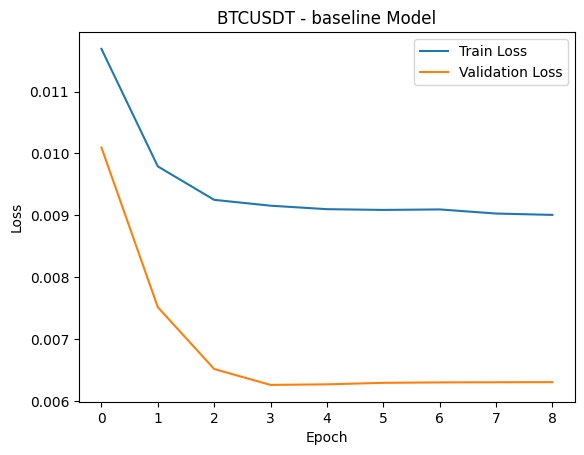

regime model for BTCUSDT:


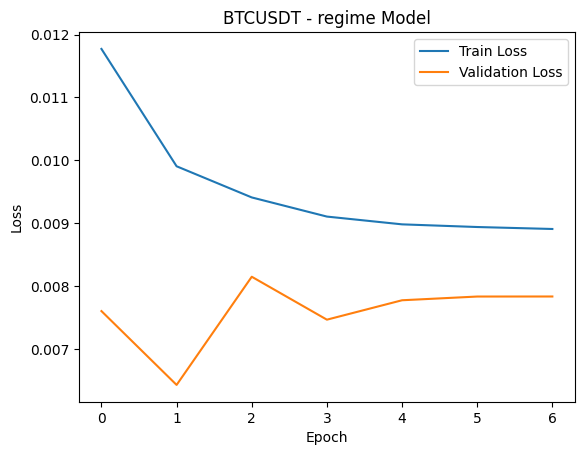

baseline model for ETHUSDT:


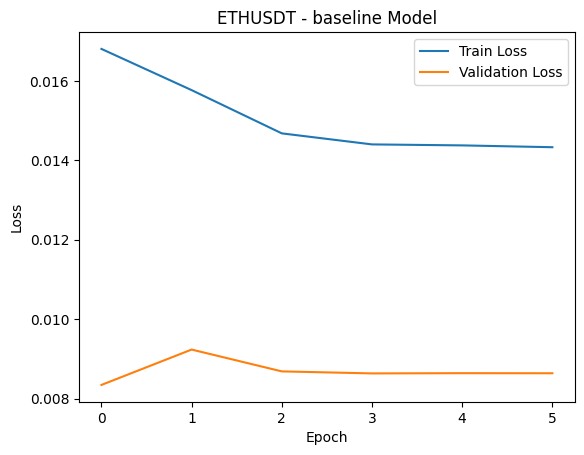

regime model for ETHUSDT:


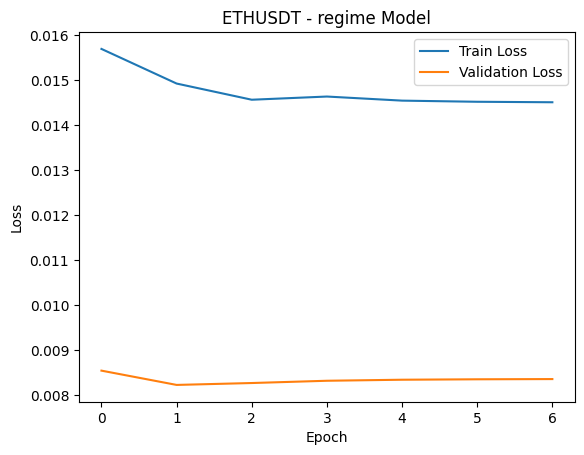

baseline model for BNBUSDT:


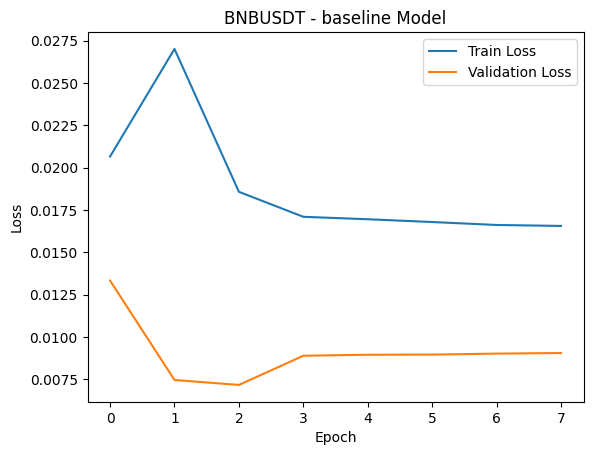

regime model for BNBUSDT:


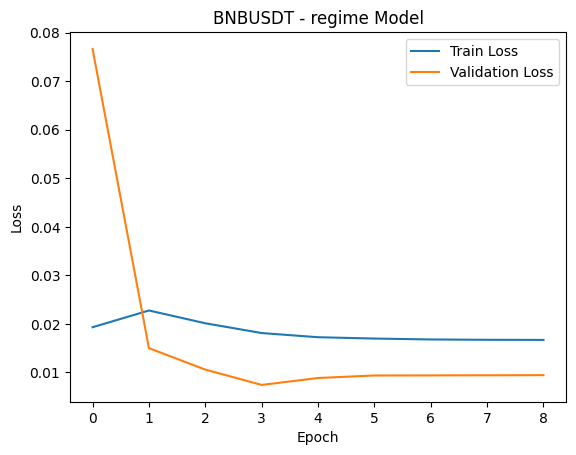

baseline model for ADAUSDT:


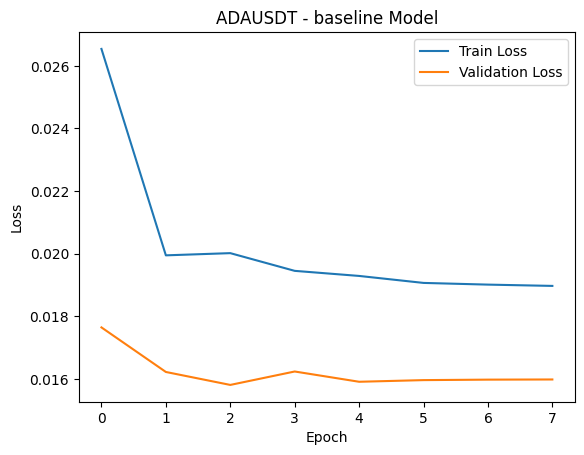

regime model for ADAUSDT:


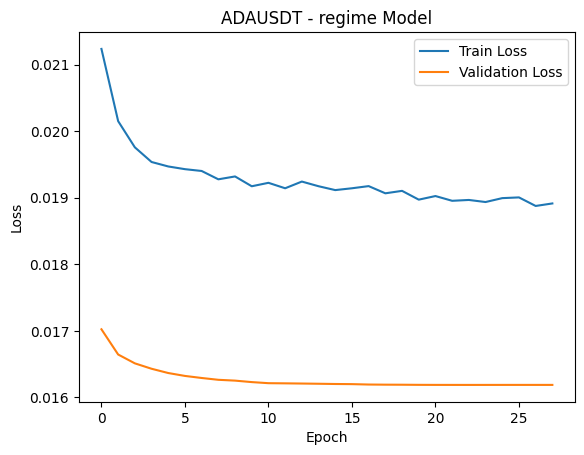

baseline model for XRPUSDT:


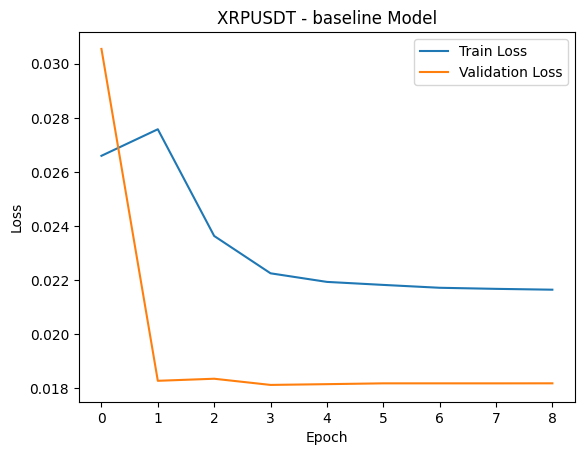

regime model for XRPUSDT:


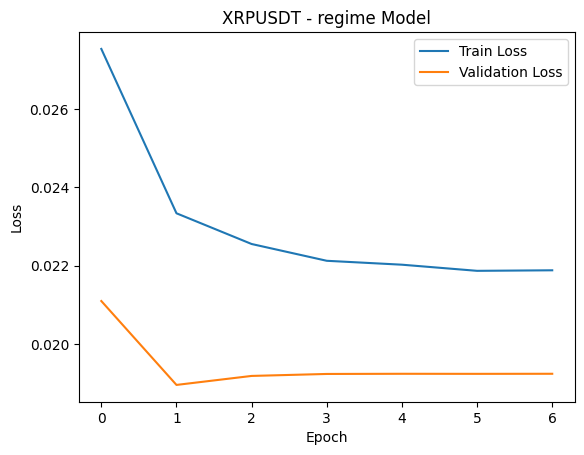

baseline model for LTCUSDT:


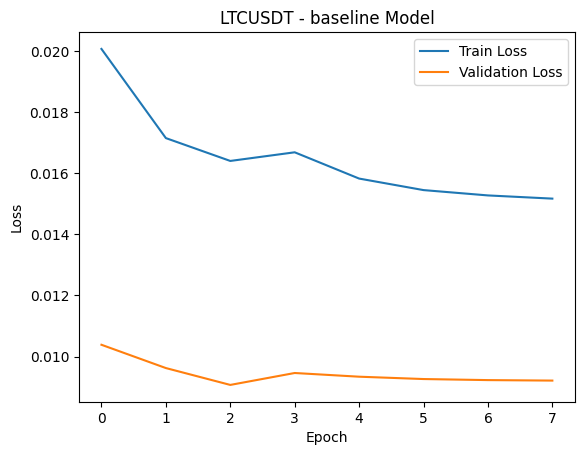

regime model for LTCUSDT:


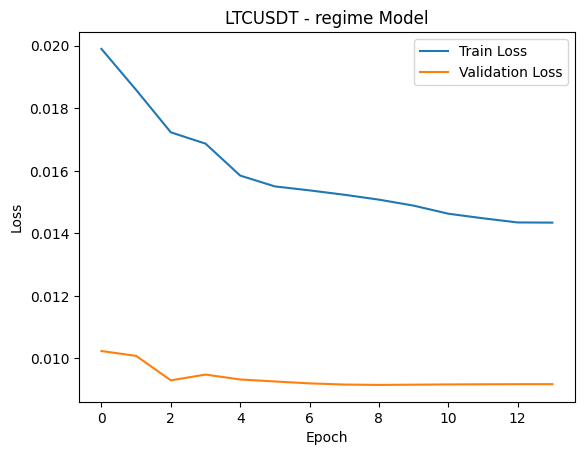

baseline model for BCHUSDT:


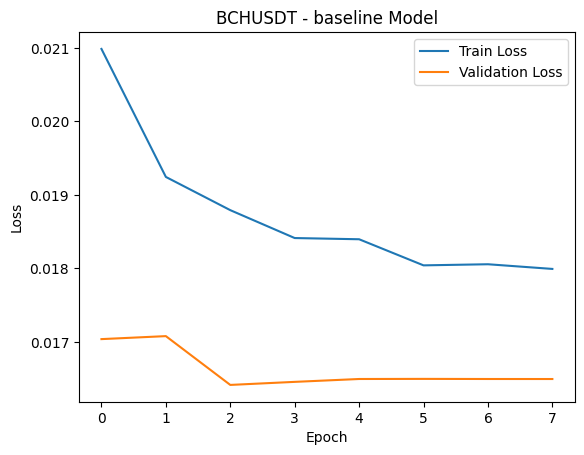

regime model for BCHUSDT:


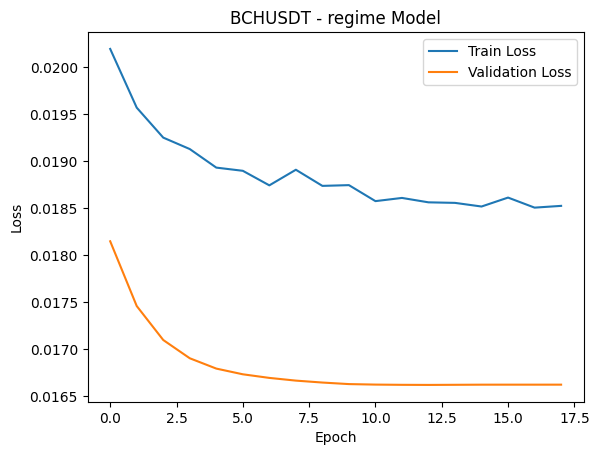

baseline model for LINKUSDT:


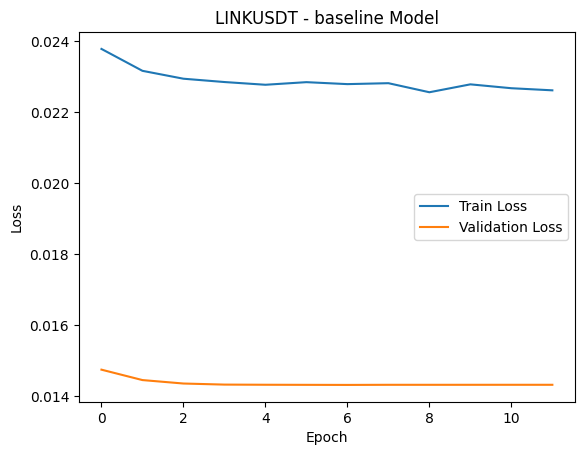

regime model for LINKUSDT:


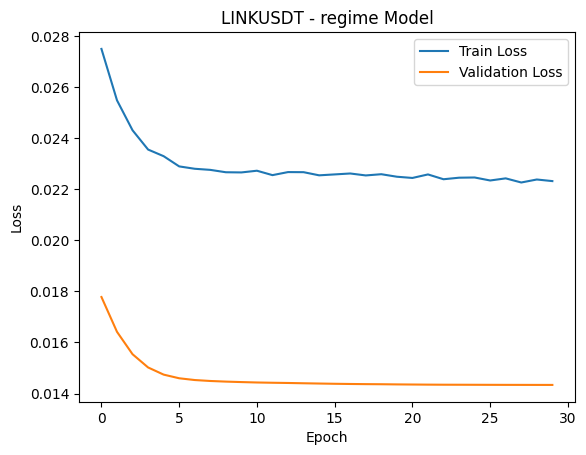

In [153]:
# load final model training metadata
print(assets)
for asset in assets:
    for type in ["baseline", "regime"]:
        metadata = np.load(f"{MODEL_DIR}/{type}_metadata_{asset}.npy", allow_pickle=True).item()
        train_losses = metadata["training"]["train_losses"]
        val_losses = metadata["training"]["val_losses"]

        print(f"{type} model for {asset}:")
        plt.plot(train_losses, label="Train Loss")
        plt.plot(val_losses, label="Validation Loss")
        plt.title(f"{asset} - {type} Model")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.legend()
        plt.show()

### Comparison of baseline model vs regime-aware model (Validation Loss) per-asset

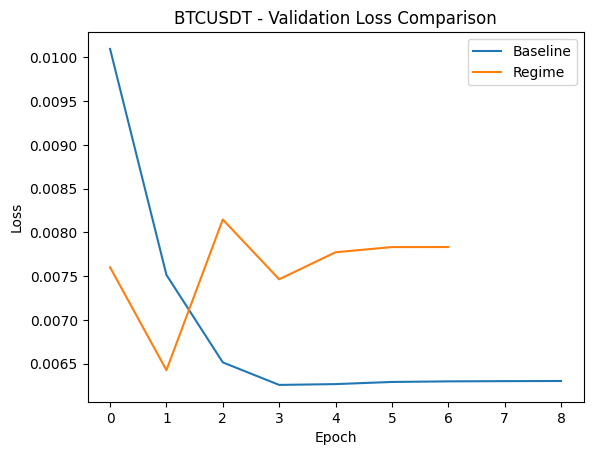

Baseline best val: 0.006257316685206462
Regime best val: 0.0064259906789718565


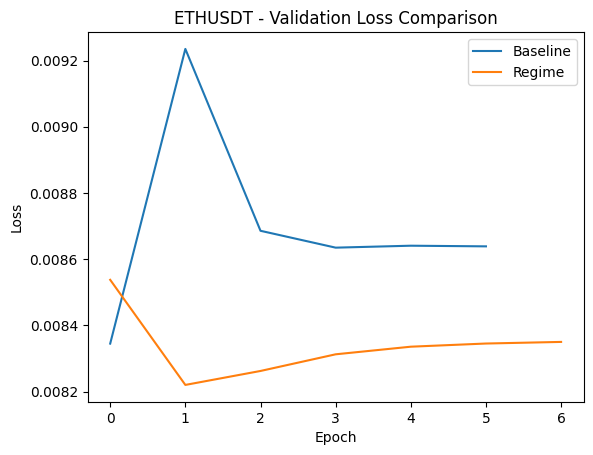

Baseline best val: 0.008345182147136471
Regime best val: 0.008220419761125506


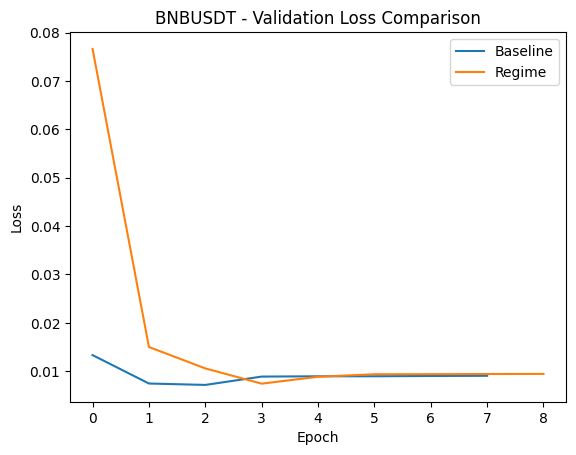

Baseline best val: 0.007166276628820843
Regime best val: 0.007428902040513279


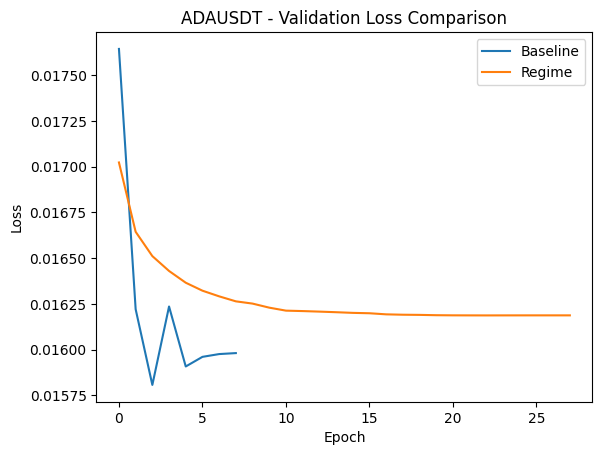

Baseline best val: 0.01580718112460916
Regime best val: 0.01618720403247225


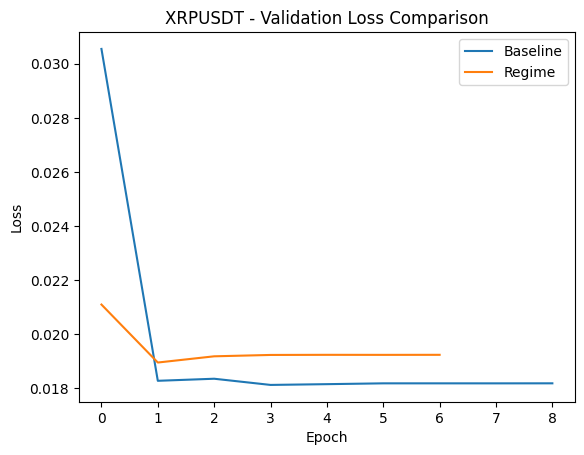

Baseline best val: 0.018124858648996166
Regime best val: 0.018953013864234296


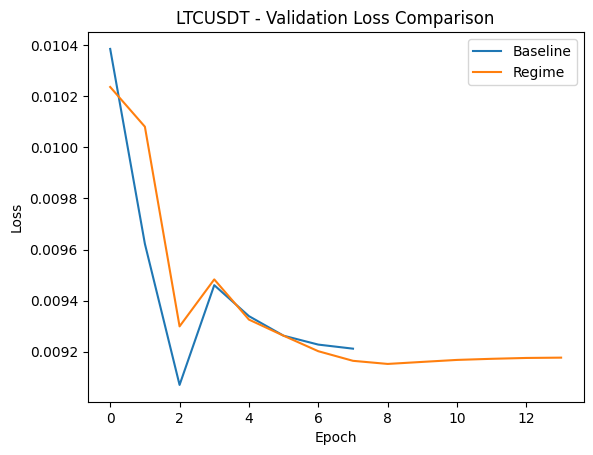

Baseline best val: 0.009070237787196563
Regime best val: 0.009152377449743928


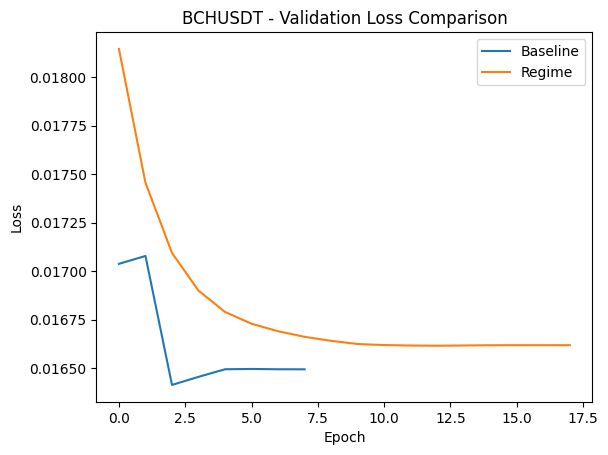

Baseline best val: 0.016414391831559724
Regime best val: 0.01661620167418692


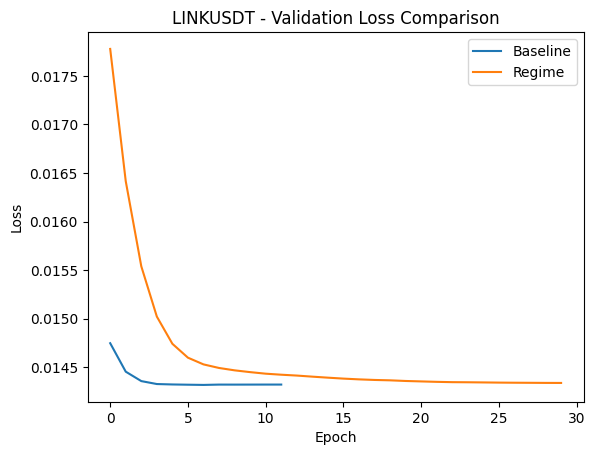

Baseline best val: 0.014316816713069475
Regime best val: 0.014337198243250754


In [154]:
for asset in assets:
    base = np.load(f"models/baseline_metadata_{asset}.npy", allow_pickle=True).item()
    reg  = np.load(f"models/regime_metadata_{asset}.npy", allow_pickle=True).item()

    # plot validation loss
    plt.plot(base["training"]["val_losses"], label="Baseline")
    plt.plot(reg["training"]["val_losses"], label="Regime")

    plt.title(f"{asset} - Validation Loss Comparison")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    # best val loss
    print("Baseline best val:", base['training']['best_val_loss'])
    print("Regime best val:", reg['training']['best_val_loss'])

### Final results
- Best set of hyparameters
- Best validation loss

In [155]:
results = np.load("models/all_results.npy", allow_pickle=True).item()

# For each asset, get best hyperparamaters and best val loss
for asset in assets:
    print(f"{asset}:")
    print(results[asset]['baseline'])
    print(results[asset]['regime'])

BTCUSDT:
{'config': {'learning_rate': 5e-05, 'hidden_size': 128, 'dropout': 0.3}, 'best_val_loss': 0.006257316685206462}
{'config': {'learning_rate': 0.001, 'hidden_size': 128, 'dropout': 0.1}, 'best_val_loss': 0.0064259906789718565}
ETHUSDT:
{'config': {'learning_rate': 0.0005, 'hidden_size': 64, 'dropout': 0.3}, 'best_val_loss': 0.008345182147136471}
{'config': {'learning_rate': 5e-05, 'hidden_size': 64, 'dropout': 0.3}, 'best_val_loss': 0.008220419761125506}
BNBUSDT:
{'config': {'learning_rate': 0.001, 'hidden_size': 64, 'dropout': 0.1}, 'best_val_loss': 0.007166276628820843}
{'config': {'learning_rate': 0.001, 'hidden_size': 128, 'dropout': 0.1}, 'best_val_loss': 0.007428902040513279}
ADAUSDT:
{'config': {'learning_rate': 0.001, 'hidden_size': 128, 'dropout': 0.1}, 'best_val_loss': 0.01580718112460916}
{'config': {'learning_rate': 5e-05, 'hidden_size': 128, 'dropout': 0.3}, 'best_val_loss': 0.01618720403247225}
XRPUSDT:
{'config': {'learning_rate': 0.001, 'hidden_size': 64, 'dropou

### Evaluate forecast accuracy per-asset

- Lower MSE is better
- Higher directional accuracy is better

In [159]:
for asset, data in results.items():
    mse_base = data['results'][0]['mse_no_regime']
    mse_reg = data['results'][0]['mse_with_regime']
    da_base = data['results'][0]['da_no_regime']
    da_reg = data['results'][0]['da_with_regime']
    
    print(f"{asset}:")
    print(f"  MSE Baseline: {mse_base:.6f}, Regime: {mse_reg:.6f}")
    print(f"  Directional Acc Baseline: {da_base:.2%}, Regime: {da_reg:.2%}\n")

BTCUSDT:
  MSE Baseline: 0.006302, Regime: 0.007833
  Directional Acc Baseline: 44.01%, Regime: 44.01%

ETHUSDT:
  MSE Baseline: 0.008639, Regime: 0.008350
  Directional Acc Baseline: 48.47%, Regime: 58.22%

BNBUSDT:
  MSE Baseline: 0.009052, Regime: 0.009444
  Directional Acc Baseline: 48.47%, Regime: 47.35%

ADAUSDT:
  MSE Baseline: 0.015981, Regime: 0.016187
  Directional Acc Baseline: 52.37%, Regime: 52.09%

XRPUSDT:
  MSE Baseline: 0.018184, Regime: 0.019238
  Directional Acc Baseline: 48.47%, Regime: 47.63%

LTCUSDT:
  MSE Baseline: 0.009212, Regime: 0.009177
  Directional Acc Baseline: 54.04%, Regime: 55.71%

BCHUSDT:
  MSE Baseline: 0.016495, Regime: 0.016619
  Directional Acc Baseline: 46.80%, Regime: 48.75%

LINKUSDT:
  MSE Baseline: 0.014320, Regime: 0.014337
  Directional Acc Baseline: 57.66%, Regime: 55.15%



## Get `all_forecasts.csv`

In [ ]:
# ===== CONFIG =====
LOOKBACK = 30           # same as used in training
REBALANCE_FREQ = 7       # rebalancing every 7 days
assets = ["BTCUSDT", "ETHUSDT", "BNBUSDT", "ADAUSDT", "XRPUSDT", "LTCUSDT", "BCHUSDT", "LINKUSDT"]
MODEL_DIR = Path("models")

# ===== LOAD PRE-PROCESSED SEQUENCES =====
# These are the sequences you created with build_lstm_sequences
X_test_dict = {asset: np.load(f"lstm_ready_data/X_test_{asset}.npy") for asset in assets}
y_test_dict = {asset: np.load(f"lstm_ready_data/y_test_{asset}.npy") for asset in assets}
meta_test_dict = {
    asset: np.load(f"lstm_ready_data/meta_test_{asset}.npy", allow_pickle=True)
    if Path(f"lstm_ready_data/meta_test_{asset}.npy").exists()
    else None
    for asset in assets
}

X_val_dict = {asset: np.load(f"lstm_ready_data/X_val_{asset}.npy") for asset in assets}
y_val_dict = {asset: np.load(f"lstm_ready_data/y_val_{asset}.npy") for asset in assets}
meta_val_dict = {
    asset: np.load(f"lstm_ready_data/meta_val_{asset}.npy", allow_pickle=True)
    if Path(f"lstm_ready_data/meta_val_{asset}.npy").exists()
    else None
    for asset in assets
}


def load_model(asset: str, model_type: str = "baseline", model_dir: str = "models", input_size: int = None, device: str = "cpu"):
    """
    Load a trained CryptoLSTM model with the correct architecture from saved metadata and checkpoint.

    Args:
        asset: crypto symbol, e.g., 'BTCUSDT'
        model_type: "baseline" or "regime"
        model_dir: directory where models and metadata are saved
        input_size: number of features in X (required)
        device: 'cpu' or 'cuda'

    Returns:
        model: loaded CryptoLSTM ready for prediction
    """
    assert model_type in ["baseline", "regime"], "model_type must be 'baseline' or 'regime'"
    assert input_size is not None, "input_size must be provided"

    metadata_path = f"{model_dir}/{model_type}_metadata_{asset}.npy"
    checkpoint_path = f"{model_dir}/{model_type}_{asset}.pt"

    # load hyperparameters from metadata
    metadata = np.load(metadata_path, allow_pickle=True).item()
    hyperparams = metadata["hyperparameters"]

    model = CryptoLSTM(
        input_size=input_size,
        hidden_size=hyperparams["hidden_size"],
        dropout=hyperparams["dropout"],
        num_layers=hyperparams.get("num_layers", 2)  # default to 2 if missing
    ).to(device)

    # load checkpoint
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    return model


# -- For val set ---
y_pred_base_dict_val = {}
y_pred_reg_dict_val  = {}

for asset in assets: 
    X_val_asset = X_val_dict[asset]  # your preprocessed LSTM array for this asset
    X_val_baseline = X_val_asset[:, :, :11]
    X_val_regime = X_val_asset[:, :, :12]

    # load baseline model
    model_base = load_model(asset, model_type="baseline", input_size=X_val_baseline.shape[2], device="cpu")

    # load regime-aware model
    model_reg = load_model(asset, model_type="regime", input_size=X_val_regime.shape[2], device="cpu")

    # get predictions
    y_pred_base_dict_val[asset] = predict_model(model_base, X_val_baseline)
    y_pred_reg_dict_val[asset]  = predict_model(model_reg, X_val_regime)


# -- For test set ---
y_pred_base_dict_test = {}
y_pred_reg_dict_test  = {}

for asset in assets: 
    X_test_asset = X_test_dict[asset]  # your preprocessed LSTM array for this asset
    X_test_baseline = X_test_asset[:, :, :11]
    X_test_regime = X_test_asset[:, :, :12]

    # load baseline model
    model_base = load_model(asset, model_type="baseline", input_size=X_test_baseline.shape[2], device="cpu")

    # load regime-aware model
    model_reg = load_model(asset, model_type="regime", input_size=X_test_regime.shape[2], device="cpu")

    # get predictions
    y_pred_base_dict_test[asset] = predict_model(model_base, X_test_baseline)
    y_pred_reg_dict_test[asset]  = predict_model(model_reg, X_test_regime)


In [56]:
print(meta_test_dict["BTCUSDT"].shape)
print(meta_test_dict["BTCUSDT"])


(358, 2)
[['BTCUSDT' Timestamp('2025-01-01 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-02 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-03 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-04 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-05 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-06 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-07 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-08 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-09 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-10 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-11 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-12 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-13 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-14 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-15 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-16 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-17 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-18 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-19 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-20 00:00:00')]
 ['BTCUSDT' Timestamp('2025-01-21 00:00:00')]
 ['BTCUSDT' Timestamp('20

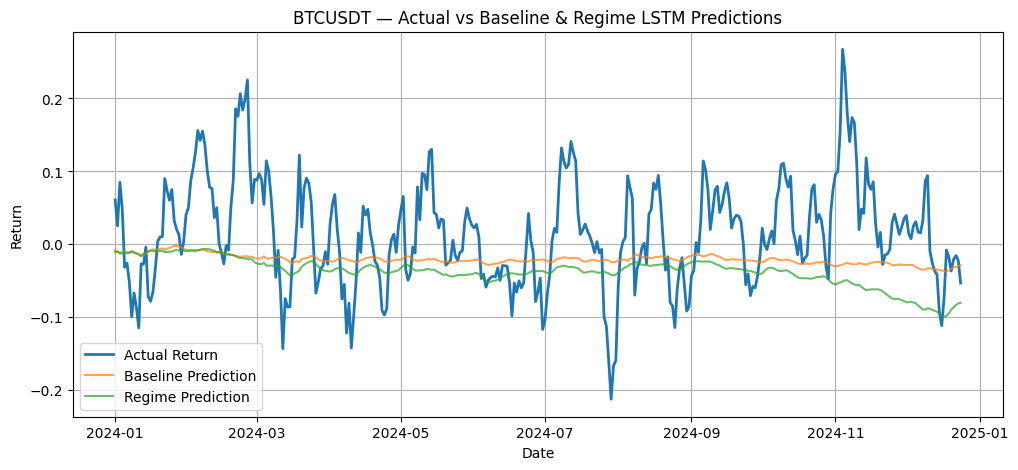

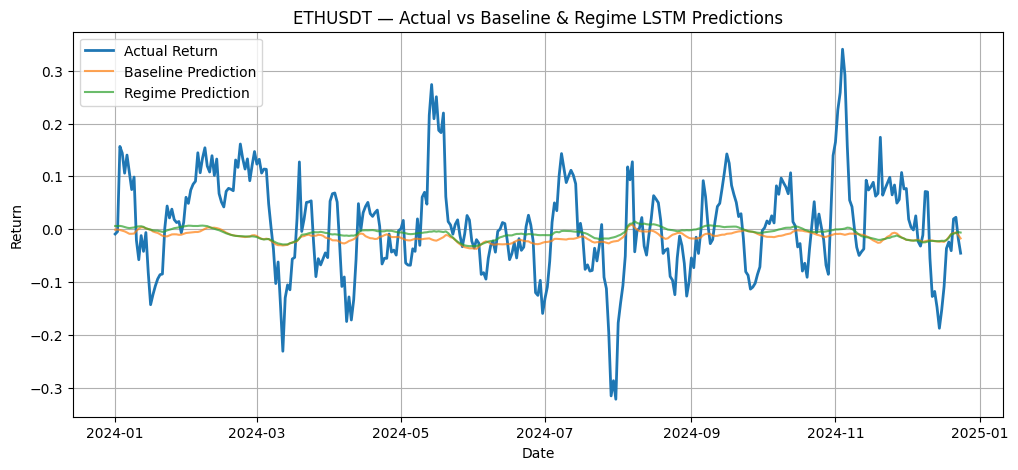

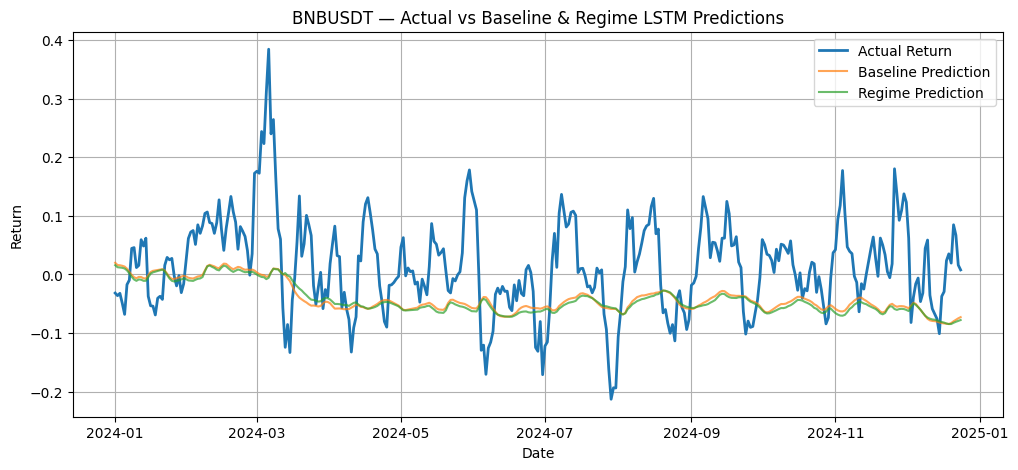

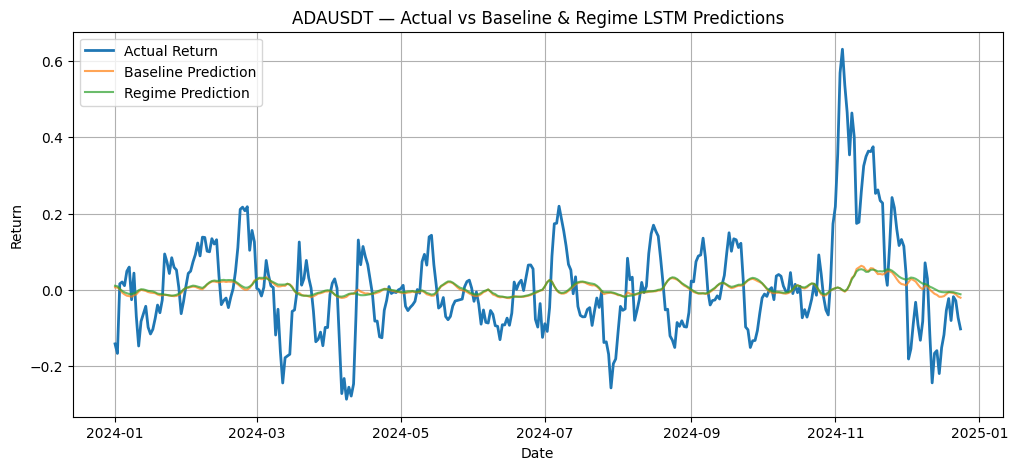

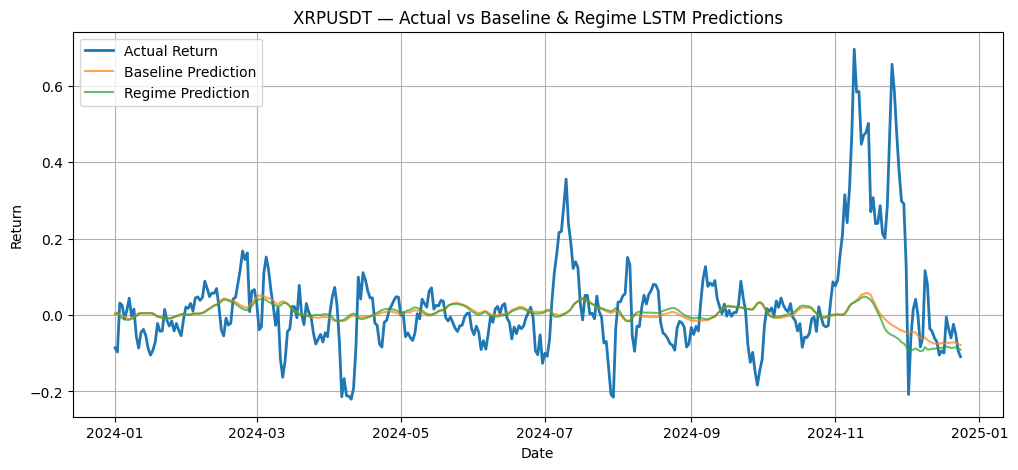

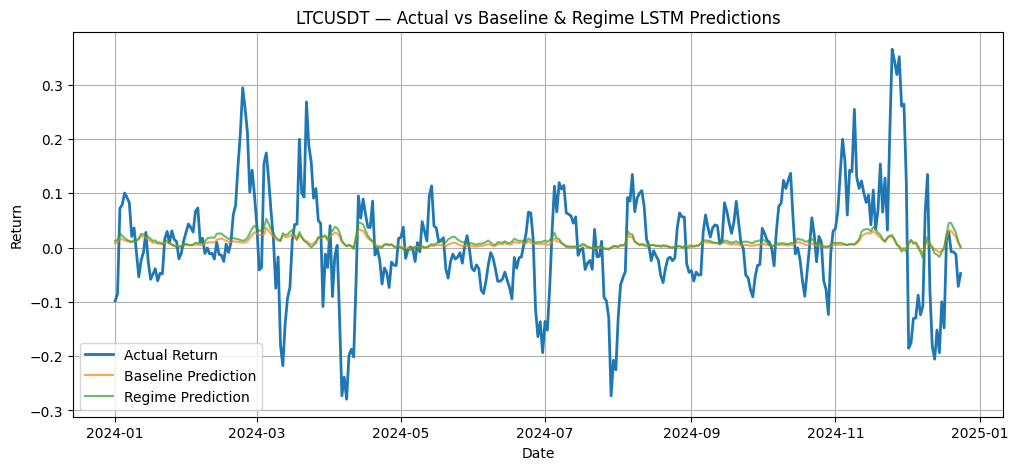

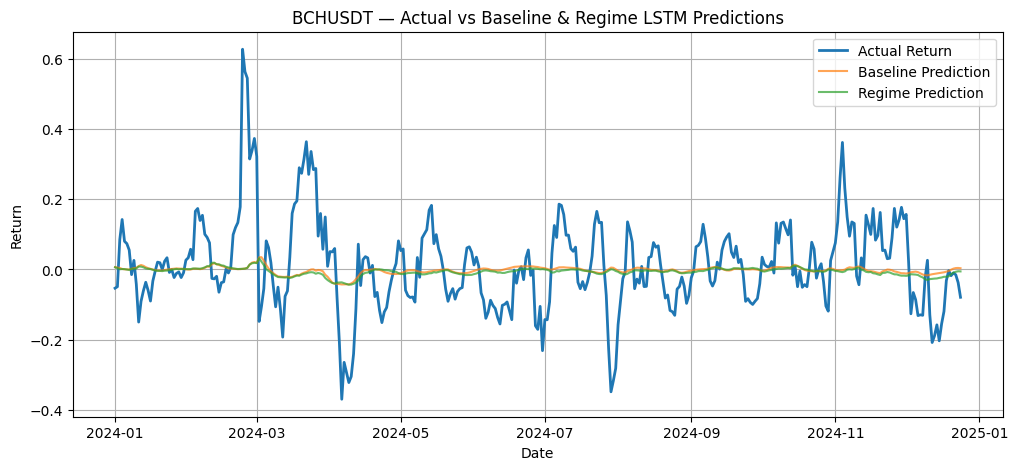

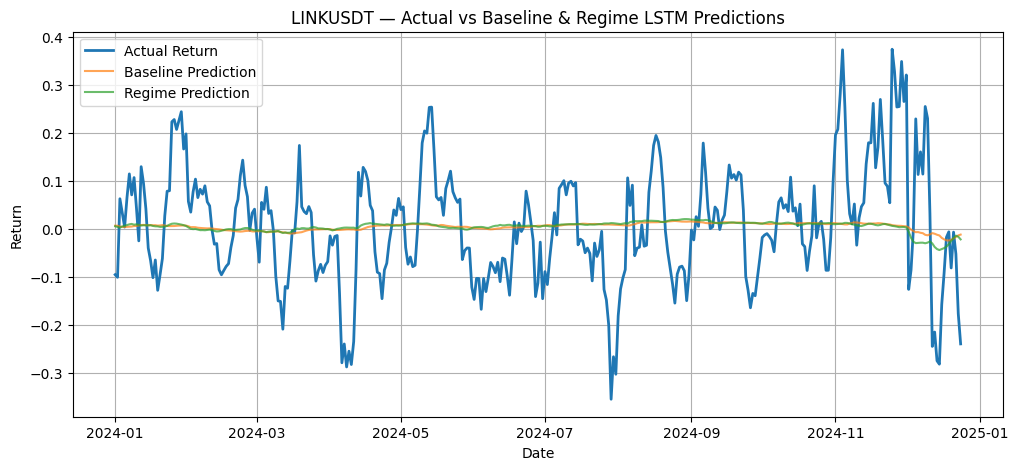

In [ ]:
def plot_asset_predictions(asset, actual_df, pred_base_df, pred_reg_df, start=None, end=None):
    plt.figure(figsize=(12,5))
    
    plt.plot(actual_df.loc[start:end, asset], label="Actual Return", linewidth=2)
    plt.plot(pred_base_df.loc[start:end, asset], label="Baseline Prediction", alpha=0.7)
    plt.plot(pred_reg_df.loc[start:end, asset], label="Regime Prediction", alpha=0.7)
    
    plt.title(f"{asset} — Actual vs Baseline & Regime LSTM Predictions")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True)
    plt.show()


# --- Build a prediction DF for baseline and regime (val set) ---
pred_base_df_val = {}
pred_reg_df_val  = {}
actual_df_val    = {}

for asset in assets:
    dates_val = pd.to_datetime(meta_val_dict[asset][:, 1])
    
    pred_base_df_val[asset] = pd.Series(y_pred_base_dict_val[asset], index=dates_val)
    pred_reg_df_val[asset]  = pd.Series(y_pred_reg_dict_val[asset],  index=dates_val)
    actual_df_val[asset]    = pd.Series(y_val_dict[asset],      index=dates_val)

pred_base_df_val = pd.DataFrame(pred_base_df_val)
pred_reg_df_val  = pd.DataFrame(pred_reg_df_val)
actual_df_val    = pd.DataFrame(actual_df_val)

# Example: plot all assets
for asset in assets:
    plot_asset_predictions(asset, actual_df_val, pred_base_df_val, pred_reg_df_val)


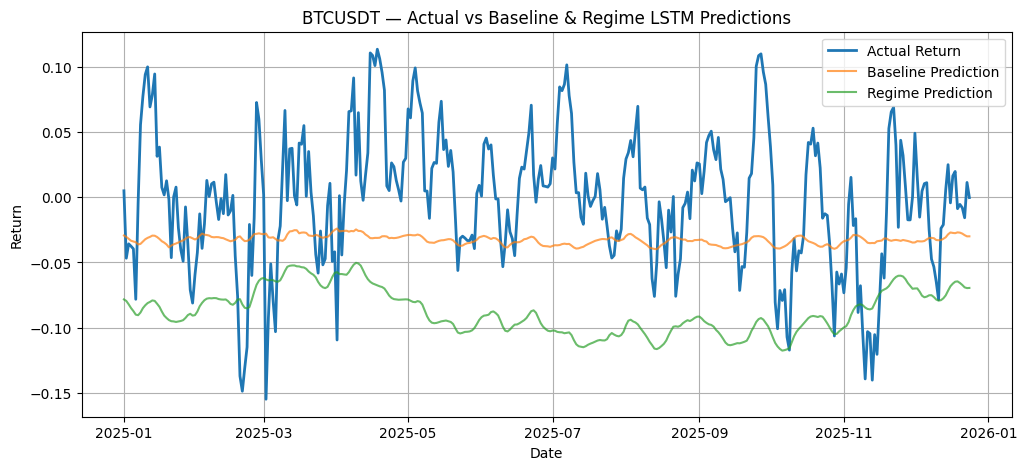

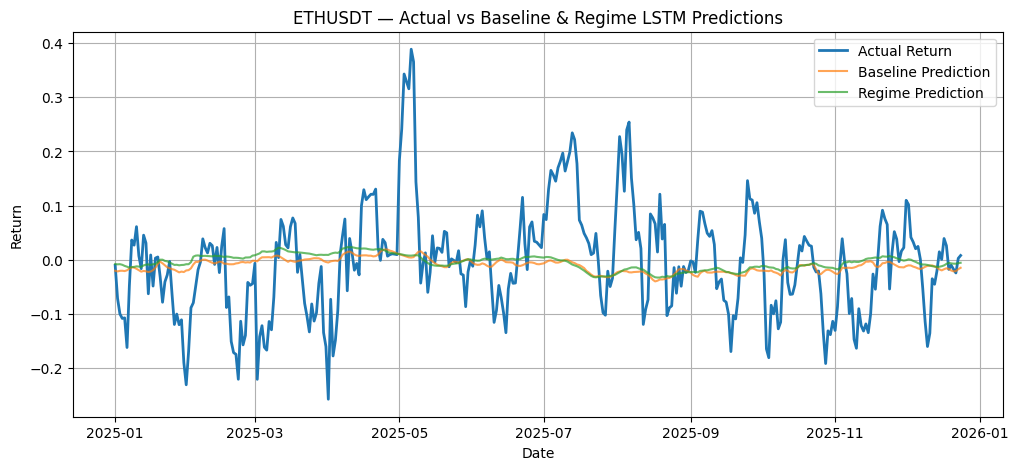

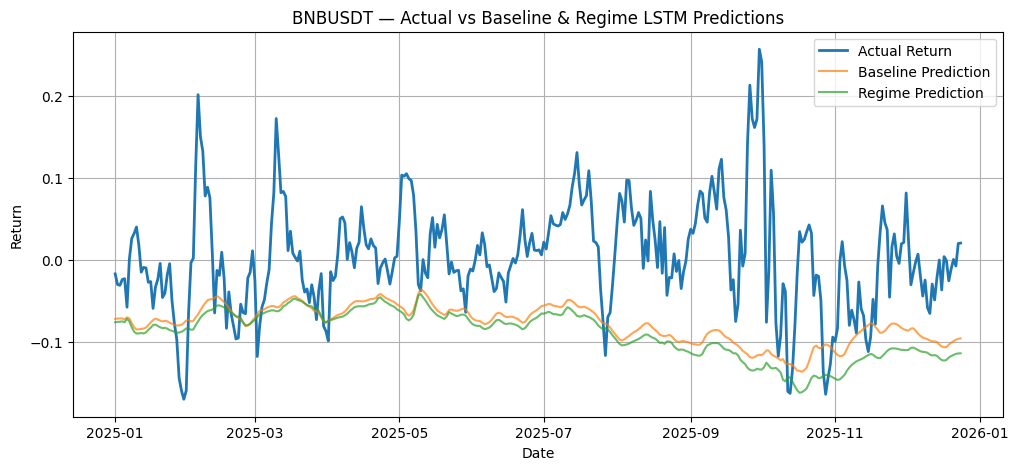

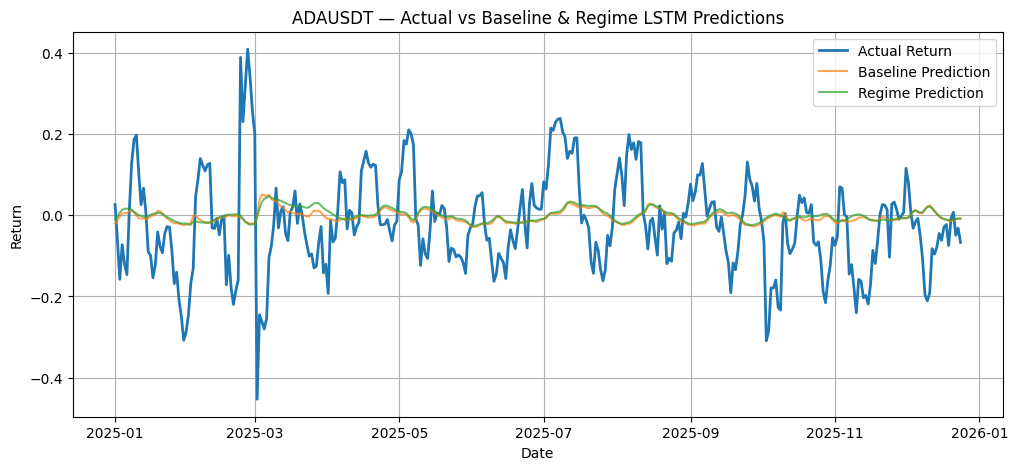

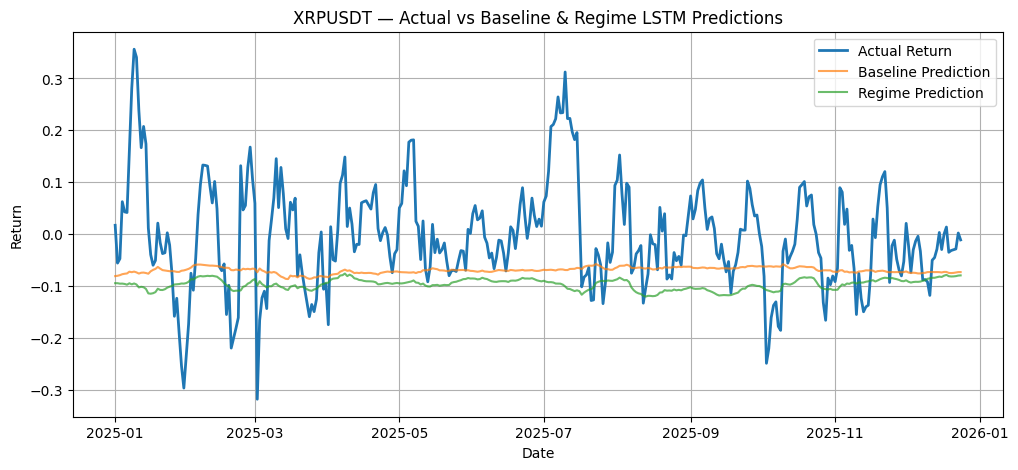

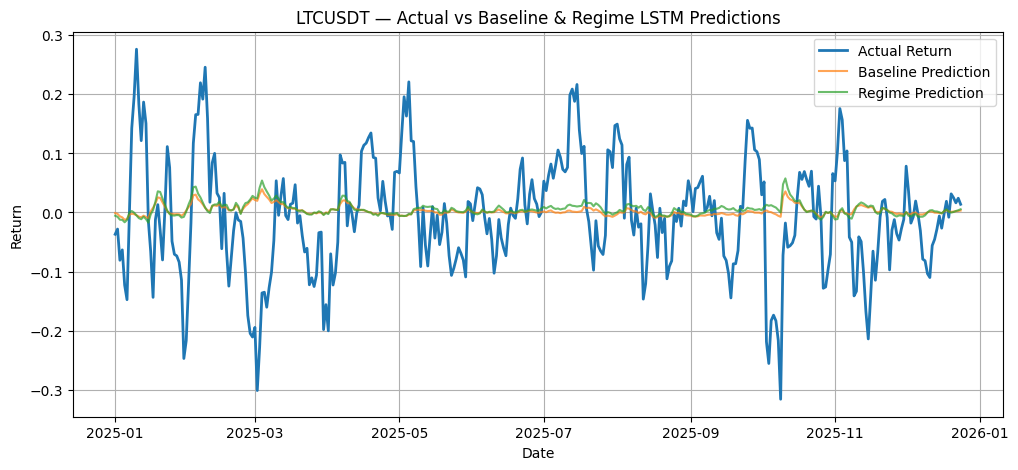

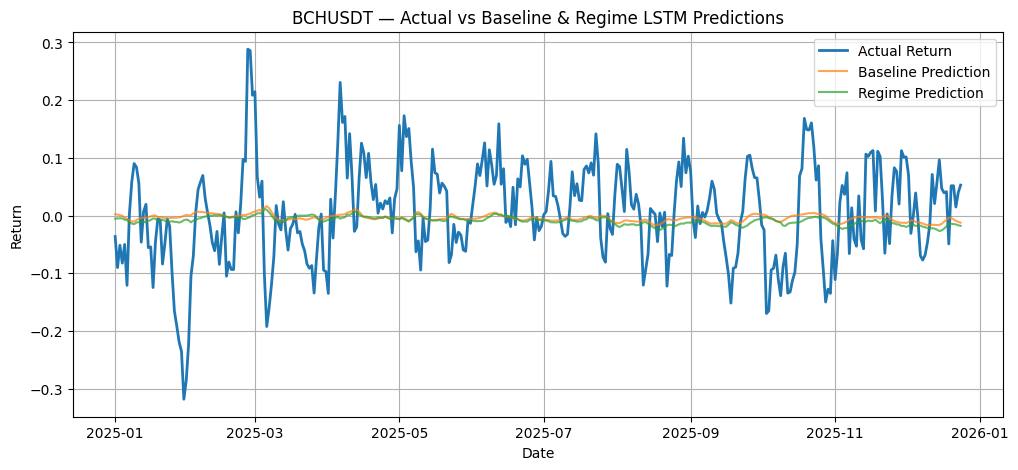

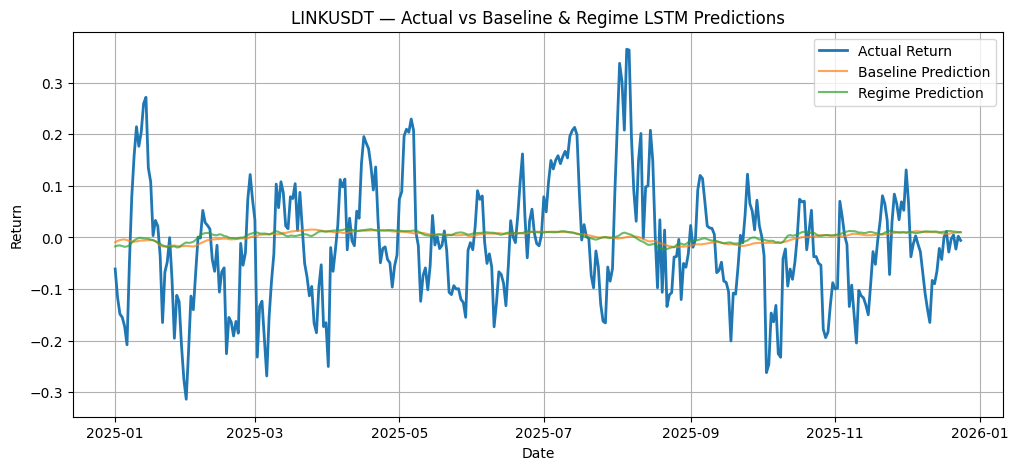

In [61]:
# --- Build a prediction DF for baseline and regime (test set) ---
pred_base_df_test = {}
pred_reg_df_test  = {}
actual_df_test    = {}

for asset in assets:
    dates_test = pd.to_datetime(meta_test_dict[asset][:, 1])
    
    pred_base_df_test[asset] = pd.Series(y_pred_base_dict_test[asset], index=dates_test)
    pred_reg_df_test[asset]  = pd.Series(y_pred_reg_dict_test[asset],  index=dates_test)
    actual_df_test[asset]    = pd.Series(y_test_dict[asset],      index=dates_test)

pred_base_df_test = pd.DataFrame(pred_base_df_test)
pred_reg_df_test  = pd.DataFrame(pred_reg_df_test)
actual_df_test    = pd.DataFrame(actual_df_test)

# Example: plot all assets
for asset in assets:
    plot_asset_predictions(asset, actual_df_test, pred_base_df_test, pred_reg_df_test)

In [ ]:
# --- For val set ---
rows = []

for asset in assets:    
    dates_val = pd.to_datetime(meta_val_dict[asset][:, 1]) 
    
    for model_type in ["baseline", "regime"]:
        if model_type == "baseline":
            y_pred = y_pred_base_dict_val[asset]
        else:
            y_pred = y_pred_reg_dict_val[asset]
        for i in range(len(dates_val)):
            rows.append({
                "crypto": asset,
                "date": dates_val[i],
                "split": "val",         
                "model_type": model_type,  
                "y_true": float(y_val_dict[asset][i]),
                "y_pred": float(y_pred[i])
            })


# --- For test set ---
for asset in assets:    
    dates_test = pd.to_datetime(meta_test_dict[asset][:, 1]) 
    
    for model_type in ["baseline", "regime"]:
        if model_type == "baseline":
            y_pred = y_pred_base_dict_test[asset]
        else:
            y_pred = y_pred_reg_dict_test[asset]
        for i in range(len(dates_test)):
            rows.append({
                "crypto": asset,
                "date": dates_test[i],
                "split": "test",         
                "model_type": model_type, 
                "y_true": float(y_test_dict[asset][i]),
                "y_pred": float(y_pred[i])
            })

In [63]:
df_all = pd.DataFrame(rows)
df_all.to_csv("all_forecasts_new.csv", index=False)